# Fit an analytical model to the simulated magnetic field evolution

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from pypopsyn.simulator.config_simulator import cfg
import pypopsyn.simulator.magneto_rotational_physics.magneto_rotational_evolution_fit as mre
import utilities.plot_settings

In the following, we fit analytical functions to simulated magnetic-field evolution curves. The functional form we use is the following: 

if $\tau_1 < \tau_2 < \tau_{\rm late}$:

$$B(t) = B_{\rm initial} (1 + t/\tau_1)^{a_1} (1 + t/\tau_2)^{a_2-a_1} (1 + t/\tau_{\rm late})^{a_{\rm late}-a_2}$$ 

if $\tau_1 < \tau_{\rm late} < \tau_2$:

$$B(t) = B_{\rm initial} (1 + t/\tau_1)^{a_1} (1 + t/\tau_{\rm late})^{a_{\rm late}-a_1}$$ 

if $\tau_{\rm late} < \tau_1 < \tau_2$:

$$B(t) = B_{\rm initial} (1 + t/\tau_{\rm late})^{a_{\rm late}}$$ 

where $\tau_1 = A_1  B_{\rm initial}^{b_1}$ and $\tau_2 = A_2 B_{\rm initial}^{b_2}$ and $\tau_{\rm late}$ is a constant.

## Load the simulated magnetic field evolution curves

For the magneto-thermal simulations the following set-up was employed: The equation of state is SLy4 with a NS mass of 1.4 Msun and radius of 11.74 km. The impurity parameter in the pasta layer is fixed to 100. For the impurity in the outer and inner crust(excluding the pasta layer), the fits of [Carreau et al.(2020)](https://ui.adsabs.harvard.edu/abs/2020A%26A...640A..77C/abstract) have been used (see Figure 5 in that paper). The envelope model is taken from [Potekhin et al. (2015)](https://ui.adsabs.harvard.edu/abs/2015SSRv..191..239P/abstract). Superfluid and superconducting gap parametrisations are taken from [Ho et al. (2015)](https://ui.adsabs.harvard.edu/abs/2015SciA....1E0578H/abstract): SFB for crustal neutrons, TToa for core neutrons and CCDKp for core protons. 

The initial magnetic field of the simulated curves are: $10^{12}$ G, $10^{13}$ G, $10^{14}$ G, $10^{15}$ G, $3 \times 10^{15}$ G.

In [2]:
if cfg["magneto-thermal_model"] == "SLy4_dip-tor_heavy":
    simB12_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/SLy4_dip-tor_heavy-envelope/cool_curve_CC_Bdip1e12_Btor1e13.csv"
    simB13_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/SLy4_dip-tor_heavy-envelope/cool_curve_CC_Bdip1e13_Btor1e14.csv"
    simB14_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/SLy4_dip-tor_heavy-envelope/cool_curve_CC_Bdip1e14_Btor1e15.csv"
    simB15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/SLy4_dip-tor_heavy-envelope/cool_curve_CC_Bdip1e15_Btor1e16.csv"
    simB5e15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/SLy4_dip-tor_heavy-envelope/cool_curve_CC_Bdip5e15_Btor1e16.csv"
elif cfg["magneto-thermal_model"] == "BKS24_dip-tor_heavy":
    simB12_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_heavy-envelope/50-50_1e12_H.csv"
    simB13_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_heavy-envelope/50-50_1e13_H.csv"
    simB14_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_heavy-envelope/50-50_1e14_H.csv"
    simB15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_heavy-envelope/50-50_1e15_H.csv"
    simB5e15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_heavy-envelope/50-50_5e15_H.csv"    
elif cfg["magneto-thermal_model"] == "BKS24_dip-tor_light":
    simB12_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_light-envelope/50-50_1e12_L.csv"
    simB13_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_light-envelope/50-50_1e13_L.csv"
    simB14_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_light-envelope/50-50_1e14_L.csv"
    simB15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_light-envelope/50-50_1e15_L.csv"
    simB5e15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_light-envelope/50-50_5e15_L.csv"    

In [3]:
df_simB12 = pd.read_csv(
    simB12_path,
    delimiter=",",
    header=[0],
)
df_simB12.head()

,t[yr],B[G],L[erg/s],P_fill[s],Pdot_fill[s/s],chi[rad],P_vac[s],Pdot_vac[s/s],P_vacObs[s],Pdot_vacObs[s/s],bpol,etor,btorAvg
0,0.0,1.000000e+12,1.241346e+36,0.001000,1.314340e-12,1.047198,0.001000,3.755257e-13,0.001000,6.488641e-13,3.000000e+14,50,5.200000e+13
1,1.3,9.994016e+11,5.814862e+34,0.001048,1.244907e-12,1.035387,0.001014,3.698941e-13,0.001024,6.328026e-13,3.000000e+14,50,5.200000e+13
2,1.5,9.993896e+11,5.767381e+34,0.001056,1.234485e-12,1.033509,0.001016,3.690368e-13,0.001028,6.303349e-13,3.000000e+14,50,5.200000e+13
3,1.8,9.993718e+11,5.716754e+34,0.001068,1.219300e-12,1.030736,0.001020,3.677624e-13,0.001034,6.266874e-13,3.000000e+14,50,5.200000e+13
4,2.1,9.993540e+11,5.680060e+34,0.001079,1.204625e-12,1.028014,0.001023,3.665009e-13,0.001040,6.231021e-13,3.000000e+14,50,5.200000e+13


In [4]:
df_simB13 = pd.read_csv(
    simB13_path,
    delimiter=",",
    header=[0],
)
df_simB13.head()

,t[yr],B[G],L[erg/s],P_fill[s],Pdot_fill[s/s],chi[rad],P_vac[s],Pdot_vac[s/s],P_vacObs[s],Pdot_vacObs[s/s],bpol,etor,btorAvg
0,0.0,1.000000e+13,9.740231e+35,0.001000,1.314340e-10,1.047198,0.001000,3.755257e-11,0.001000,6.488641e-11,3.000000e+14,50,5.200000e+13
1,1.3,9.994012e+12,5.695247e+34,0.003120,3.406759e-11,0.701914,0.001961,1.912450e-11,0.002434,2.663380e-11,3.000000e+14,50,5.200000e+13
2,1.5,9.993894e+12,5.620201e+34,0.003327,3.144739e-11,0.679400,0.002079,1.804344e-11,0.002597,2.496048e-11,3.000000e+14,50,5.200000e+13
3,1.8,9.993716e+12,5.540924e+34,0.003611,2.839491e-11,0.650556,0.002244,1.671823e-11,0.002824,2.295281e-11,3.000000e+14,50,5.200000e+13
4,2.1,9.993540e+12,5.487035e+34,0.003869,2.604620e-11,0.626102,0.002397,1.564781e-11,0.003034,2.136292e-11,3.000000e+14,50,5.200000e+13


In [5]:
df_simB14 = pd.read_csv(
    simB14_path,
    delimiter=",",
    header=[0],
)
df_simB14.head()

,t[yr],B[G],L[erg/s],P_fill[s],Pdot_fill[s/s],chi[rad],P_vac[s],Pdot_vac[s/s],P_vacObs[s],Pdot_vacObs[s/s],bpol,etor,btorAvg
0,0.0,1.000000e+14,1.033371e+36,0.001000,1.314335e-08,1.047198,0.001000,3.755243e-09,0.001000,6.488616e-09,3.000000e+14,50,5.200000e+13
1,1.3,9.993763e+13,8.082915e+34,0.024537,3.101831e-10,0.120769,0.016933,2.215171e-10,0.022245,2.913613e-10,3.000000e+14,50,5.200000e+13
2,1.5,9.993584e+13,7.852922e+34,0.026427,2.874299e-10,0.112250,0.018283,2.051593e-10,0.024020,2.698221e-10,3.000000e+14,50,5.200000e+13
3,1.8,9.993306e+13,7.566281e+34,0.029027,2.611224e-10,0.102300,0.020138,1.862489e-10,0.026459,2.449286e-10,3.000000e+14,50,5.200000e+13
4,2.1,9.993018e+13,7.335651e+34,0.031408,2.409511e-10,0.094603,0.021836,1.717558e-10,0.028692,2.258546e-10,3.000000e+14,50,5.200000e+13


In [6]:
df_simB15 = pd.read_csv(
    simB15_path,
    delimiter=",",
    header=[0],
)
df_simB15.head()

,t[yr],B[G],L[erg/s],P_fill[s],Pdot_fill[s/s],chi[rad],P_vac[s],Pdot_vac[s/s],P_vacObs[s],Pdot_vacObs[s/s],bpol,etor,btorAvg
0,0.0,1.000000e+15,3.032024e+36,0.001000,1.314181e-06,1.047198,0.001000,3.754802e-07,0.001000,6.487855e-07,3.000000e+14,50,5.200000e+13
1,1.3,9.986141e+14,2.827985e+35,0.248264,3.017407e-09,-15.698928,0.170017,2.202890e-09,0.224498,2.882601e-09,3.000000e+14,50,5.200000e+13
2,1.5,9.984397e+14,2.820352e+35,0.266686,2.807959e-09,-15.699557,0.183438,2.040993e-09,0.242066,2.672454e-09,3.000000e+14,50,5.200000e+13
3,1.8,9.981714e+14,2.812940e+35,0.292138,2.561910e-09,-15.700295,0.201896,1.853397e-09,0.266243,2.428466e-09,3.000000e+14,50,5.200000e+13
4,2.1,9.978974e+14,2.804141e+35,0.315531,2.370645e-09,-15.700868,0.218793,1.709316e-09,0.288388,2.240749e-09,3.000000e+14,50,5.200000e+13


In [7]:
df_simB5e15 = pd.read_csv(
    simB5e15_path,
    delimiter=",",
    header=[0],
)
df_simB5e15.head()

,t[yr],B[G],L[erg/s],P_fill[s],Pdot_fill[s/s],chi[rad],P_vac[s],Pdot_vac[s/s],P_vacObs[s],Pdot_vacObs[s/s],bpol,etor,btorAvg
0,0.0,5.000000e+15,1.196194e+37,0.001000,3.283333e-05,1.047198,0.001000,9.380953e-06,0.001000,1.620918e-05,3.000000e+14,50,5.200000e+13
1,1.3,4.972113e+15,1.808849e+36,2.309718,1.387183e-08,-416.812551,0.970045,9.571373e-09,1.384873,1.158428e-08,3.000000e+14,50,5.200000e+13
2,1.5,4.967804e+15,1.784187e+36,2.395534,1.328571e-08,-416.822067,1.028788,9.009236e-09,1.456248,1.099743e-08,3.000000e+14,50,5.200000e+13
3,1.8,4.961464e+15,1.750659e+36,2.517831,1.252020e-08,-416.835277,1.110934,8.321778e-09,1.556995,1.025959e-08,3.000000e+14,50,5.200000e+13
4,2.1,4.955250e+15,1.721674e+36,2.633424,1.186276e-08,-416.847406,1.187231,7.767476e-09,1.651389,9.648930e-09,3.000000e+14,50,5.200000e+13


In [8]:
t12_sim = df_simB12["t[yr]"].to_numpy().astype(np.float64)
t13_sim = df_simB13["t[yr]"].to_numpy().astype(np.float64)
t14_sim = df_simB14["t[yr]"].to_numpy().astype(np.float64)
t15_sim = df_simB15["t[yr]"].to_numpy().astype(np.float64)
t5e15_sim = df_simB5e15["t[yr]"].to_numpy().astype(np.float64)

B12_sim = df_simB12["B[G]"].to_numpy().astype(np.float64)
B13_sim = df_simB13["B[G]"].to_numpy().astype(np.float64)
B14_sim = df_simB14["B[G]"].to_numpy().astype(np.float64)
B15_sim = df_simB15["B[G]"].to_numpy().astype(np.float64)
B5e15_sim = df_simB5e15["B[G]"].to_numpy().astype(np.float64)

## Evolution curves from the analytical fit model

In [9]:
log_B_initial = np.array([9, 10, 11, 12, 13, 14, 15, np.log10(5.0e15), 16, 17])
B_initial = 10**log_B_initial
time = np.logspace(0.0, 9.0, 100)

# Set the right parameters for the analytical fit of the magnetic-field evolution depending on the
# magneto-thermal model.
if cfg["magneto-thermal_model"] == "SLy4_dip-tor_heavy":
    a1 = cfg["a1_SLy4_dip-tor"]
    a2 = cfg["a2_SLy4_dip-tor"]
    A1 = cfg["A1_SLy4_dip-tor"]
    A2 = cfg["A2_SLy4_dip-tor"]
    b1 = cfg["b1_SLy4_dip-tor"]
    b2 = cfg["b2_SLy4_dip-tor"]
    tau_late = cfg["tau_late_SLy4_dip-tor"]
elif (cfg["magneto-thermal_model"] == "BKS24_dip-tor_heavy") or (
        cfg["magneto-thermal_model"] == "BKS24_dip-tor_light"
):
    a1 = cfg["a1_BKS24_dip-tor"]
    a2 = cfg["a2_BKS24_dip-tor"]
    A1 = cfg["A1_BKS24_dip-tor"]
    A2 = cfg["A2_BKS24_dip-tor"]
    b1 = cfg["b1_BKS24_dip-tor"]
    b2 = cfg["b2_BKS24_dip-tor"]
    tau_late = cfg["tau_late_BKS24_dip-tor"]
    
a_late = cfg["a_late"]

B_asymptotic = 10 ** np.random.normal(
    cfg["B_millisec_mean"], cfg["B_millisec_sigma"], len(B_initial)
)

B9_fit = mre.magnetic_field_evolution_fit_numpy(
    B_initial[0], time, B_asymptotic[0], a1, a2, A1, A2, b1, b2, tau_late, a_late
)
B10_fit = mre.magnetic_field_evolution_fit_numpy(
    B_initial[1], time, B_asymptotic[1], a1, a2, A1, A2, b1, b2, tau_late, a_late
)
B11_fit = mre.magnetic_field_evolution_fit_numpy(
    B_initial[2], time, B_asymptotic[2], a1, a2, A1, A2, b1, b2, tau_late, a_late
)
B12_fit = mre.magnetic_field_evolution_fit_numpy(
    B_initial[3], time, B_asymptotic[3], a1, a2, A1, A2, b1, b2, tau_late, a_late
)
B13_fit = mre.magnetic_field_evolution_fit_numpy(
    B_initial[4], time, B_asymptotic[4], a1, a2, A1, A2, b1, b2, tau_late, a_late
)
B14_fit = mre.magnetic_field_evolution_fit_numpy(
    B_initial[5], time, B_asymptotic[5], a1, a2, A1, A2, b1, b2, tau_late, a_late
)
B15_fit = mre.magnetic_field_evolution_fit_numpy(
    B_initial[6], time, B_asymptotic[6], a1, a2, A1, A2, b1, b2, tau_late, a_late
)
B5e15_fit = mre.magnetic_field_evolution_fit_numpy(
    B_initial[7], time, B_asymptotic[7], a1, a2, A1, A2, b1, b2, tau_late, a_late
)
B16_fit = mre.magnetic_field_evolution_fit_numpy(
    B_initial[8], time, B_asymptotic[8], a1, a2, A1, A2, b1, b2, tau_late, a_late
)
B17_fit = mre.magnetic_field_evolution_fit_numpy(
    B_initial[9], time, B_asymptotic[9], a1, a2, A1, A2, b1, b2, tau_late, a_late
)

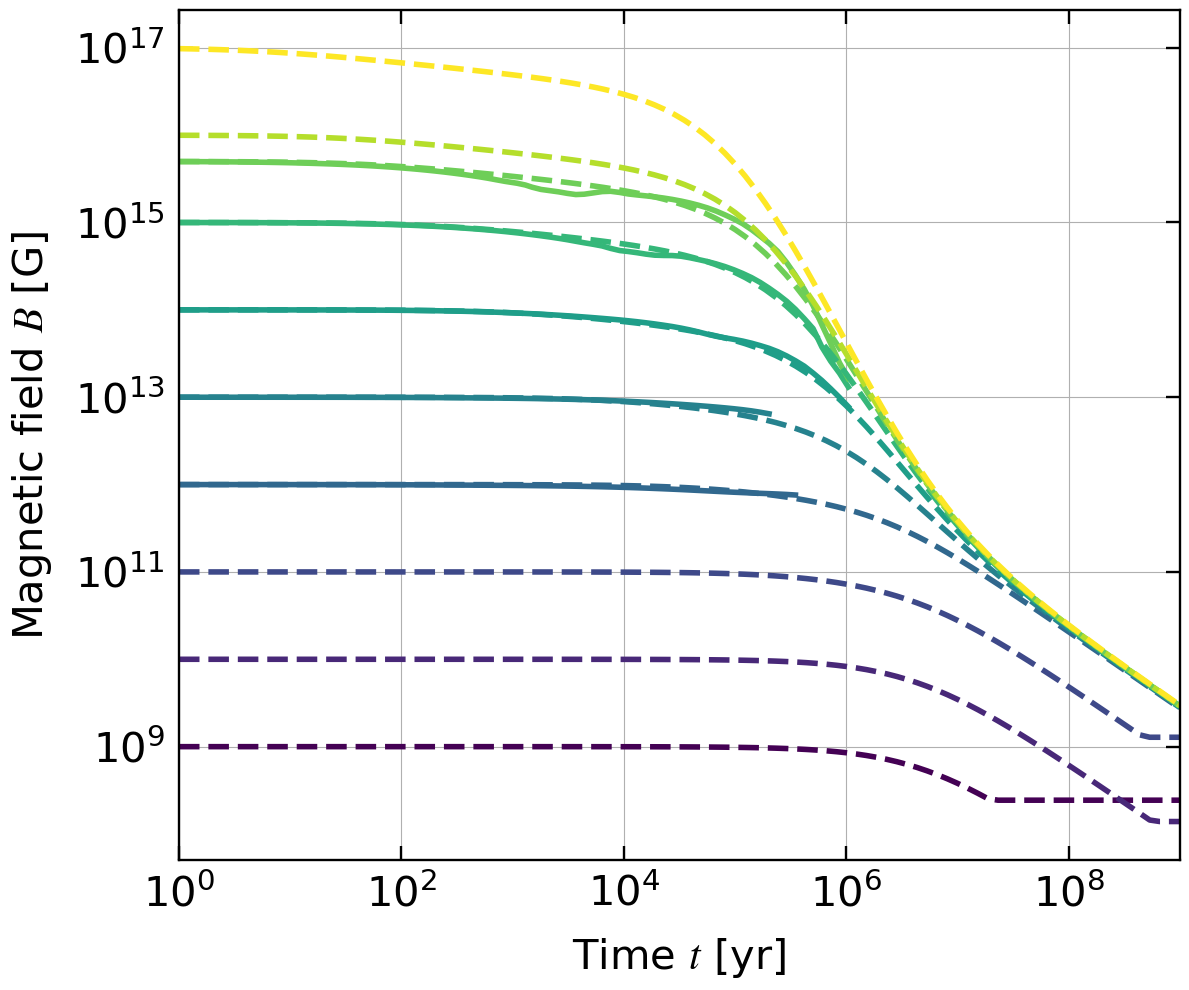

In [10]:
# plot the magnetic field evolution curves
fig, ax = plt.subplots(figsize=(12, 10))

colors = plt.get_cmap("viridis", len(log_B_initial))
norm = mpl.colors.Normalize(
    vmin=np.min(log_B_initial), vmax=np.max(log_B_initial) + 1
)
sm = plt.cm.ScalarMappable(norm=norm, cmap=colors)
sm.set_array([])

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1.0, 1.0e9)
# ax.set_ylim(1.e7,1.e17)
ax.set_xlabel(r"Time $t$ [yr]")
ax.set_ylabel(r"Magnetic field $B$ [G]")

ax.plot(
    t12_sim,
    B12_sim,
    linestyle="-",
    linewidth=4,
    color=colors(3),
    rasterized=True,
)
ax.plot(
    t13_sim,
    B13_sim,
    linestyle="-",
    linewidth=4,
    color=colors(4),
    rasterized=True,
)
ax.plot(
    t14_sim,
    B14_sim,
    linestyle="-",
    linewidth=4,
    color=colors(5),
    rasterized=True,
)
ax.plot(
    t15_sim,
    B15_sim,
    linestyle="-",
    linewidth=4,
    color=colors(6),
    rasterized=True,
)
ax.plot(
    t5e15_sim,
    B5e15_sim,
    linestyle="-",
    linewidth=4,
    color=colors(7),
    rasterized=True,
)

ax.plot(
    time,
    B9_fit,
    linestyle="--",
    linewidth=4,
    color=colors(0),
    rasterized=True,
)
ax.plot(
    time,
    B10_fit,
    linestyle="--",
    linewidth=4,
    color=colors(1),
    rasterized=True,
)

ax.plot(
    time,
    B11_fit,
    linestyle="--",
    linewidth=4,
    color=colors(2),
    rasterized=True,
)
ax.plot(
    time,
    B12_fit,
    linestyle="--",
    linewidth=4,
    color=colors(3),
    rasterized=True,
)
ax.plot(
    time,
    B13_fit,
    linestyle="--",
    linewidth=4,
    color=colors(4),
    rasterized=True,
)
ax.plot(
    time,
    B14_fit,
    linestyle="--",
    linewidth=4,
    color=colors(5),
    rasterized=True,
)
ax.plot(
    time,
    B15_fit,
    linestyle="--",
    linewidth=4,
    color=colors(6),
    rasterized=True,
)
ax.plot(
    time,
    B5e15_fit,
    linestyle="--",
    linewidth=4,
    color=colors(7),
    rasterized=True,
)
ax.plot(
    time,
    B16_fit,
    linestyle="--",
    linewidth=4,
    color=colors(8),
    rasterized=True,
)
ax.plot(
    time,
    B17_fit,
    linestyle="--",
    linewidth=4,
    color=colors(9),
    rasterized=True,
)

plt.grid()

plt.show()